# Gradient Boosting Classifier
## Dataset: Data Bantal
Notebook ini membangun model Gradient Boosting untuk memprediksi apakah konsumen menyukai produk bantal premium berdasarkan fitur demografi dan preferensi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 1. Load Dataset

In [2]:
df = pd.read_csv('../dataset/data_bantal.csv')
df

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,('Kids Signature Series','P',55,2,5,2,5,0,1,0,1,'Cukup Direkomendasikan'),NaN
297,('Signature Series','L',52,4,4,5,10,0,0,0,3,'Cukup Direkomendasikan'),NaN
298,('Kece Series','L',46,5,1,4,5,1,0,0,3,'Cukup Direkomendasikan'),NaN
299,('Deluxe Series','P',54,5,2,2,7,1,1,0,2,'Direkomendasikan'),NaN


In [3]:
df.head()

,ID,Nama Product,Jenis Kelamin,Usia,Harga,Desain,Kenyamanan,Durasi Tidur,Random Forest,Grad. Boosting,Naive Bayes,K-Means,Kesimpulan
0,INSERT INTO data_preferensi (nama,jenis_kelamin,usia,harga,desain,kenyamanan,durasi_tidur,random_forest,gradient_boosting,naive_bayes,kmeans_cluster,kesimpulan) VALUES,NaN
1,('Kece Series','P',23,4,3,1,10,0,1,1,2,'Direkomendasikan'),
2,('Kece Series','L',26,3,5,3,9,0,0,0,2,'Cukup Direkomendasikan'),NaN
3,('Premium Series','P',22,1,3,4,4,0,0,0,1,'Cukup Direkomendasikan'),NaN
4,('Kece Series','P',45,5,4,3,7,0,1,1,3,'Direkomendasikan'),NaN


In [4]:
print(df.dtypes)
print(df.head())

ID                object
Nama Product      object
Jenis Kelamin     object
Usia              object
Harga             object
Desain            object
Kenyamanan        object
Durasi Tidur      object
Random Forest     object
Grad. Boosting    object
Naive Bayes       object
K-Means           object
Kesimpulan        object
dtype: object
                                  ID    Nama Product Jenis Kelamin    Usia  \
0  INSERT INTO data_preferensi (nama   jenis_kelamin          usia   harga   
1                     ('Kece Series'             'P'            23       4   
2                     ('Kece Series'             'L'            26       3   
3                  ('Premium Series'             'P'            22       1   
4                     ('Kece Series'             'P'            45       5   

     Harga       Desain     Kenyamanan    Durasi Tidur       Random Forest  \
0   desain   kenyamanan   durasi_tidur   random_forest   gradient_boosting   
1        3            1             

## 2. Preprocessing & Feature Engineering

In [5]:
# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Encode kolom kategori
le = LabelEncoder()
df['Jenis Kelamin'] = le.fit_transform(df['Jenis Kelamin'])

# Paksa kolom numerik
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce')
df['Desain'] = pd.to_numeric(df['Desain'], errors='coerce')
df['Kenyamanan'] = pd.to_numeric(df['Kenyamanan'], errors='coerce')

# Isi missing value
df = df.fillna(0)

# Target: suka produk premium jika Harga + Desain + Kenyamanan >= 12
df['suka_premium'] = (
    (df['Harga'] + df['Desain'] + df['Kenyamanan']) >= 12
).astype(int)

df['suka_premium'].value_counts()

suka_premium
1    196
0    105
Name: count, dtype: int64

## 3. Fitur dan Target

In [6]:
print(df.columns.tolist())

X = df[['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']]
y = df['suka_premium']

# Bersihkan data agar jadi angka semua
X = X.apply(lambda col: col.astype(str).str.strip())
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

print("Shape X:", X.shape)
print("Distribusi y:", y.value_counts().to_dict())

['ID', 'Nama Product', 'Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur', 'Random Forest', 'Grad. Boosting', 'Naive Bayes', 'K-Means', 'Kesimpulan', 'suka_premium']
Shape X: (301, 6)
Distribusi y: {1: 196, 0: 105}


## 4. Split Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (240, 6), Test: (61, 6)


## 5. Training Model Gradient Boosting

In [8]:
model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model berhasil dilatih!")

✅ Model berhasil dilatih!


## 6. Prediksi

In [9]:
y_pred = model.predict(X_test)

## 7. Evaluasi Model

✅ Akurasi: 0.9180327868852459

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.95      0.93      0.94        44

    accuracy                           0.92        61
   macro avg       0.89      0.91      0.90        61
weighted avg       0.92      0.92      0.92        61



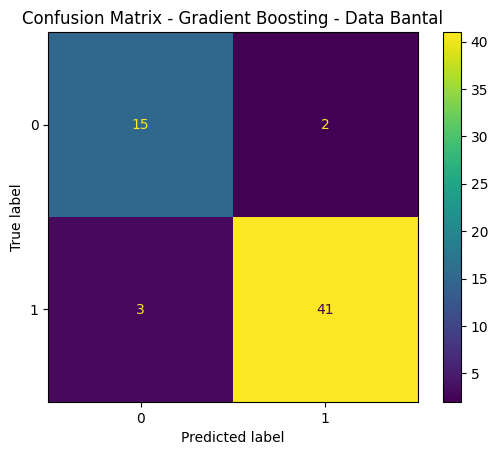

In [10]:
akurasi = accuracy_score(y_test, y_pred)
print('✅ Akurasi:', akurasi)

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix - Gradient Boosting - Data Bantal')
plt.show()

## 8. Visualisasi Pohon Gradient Boosting (3 Pohon Terakhir)

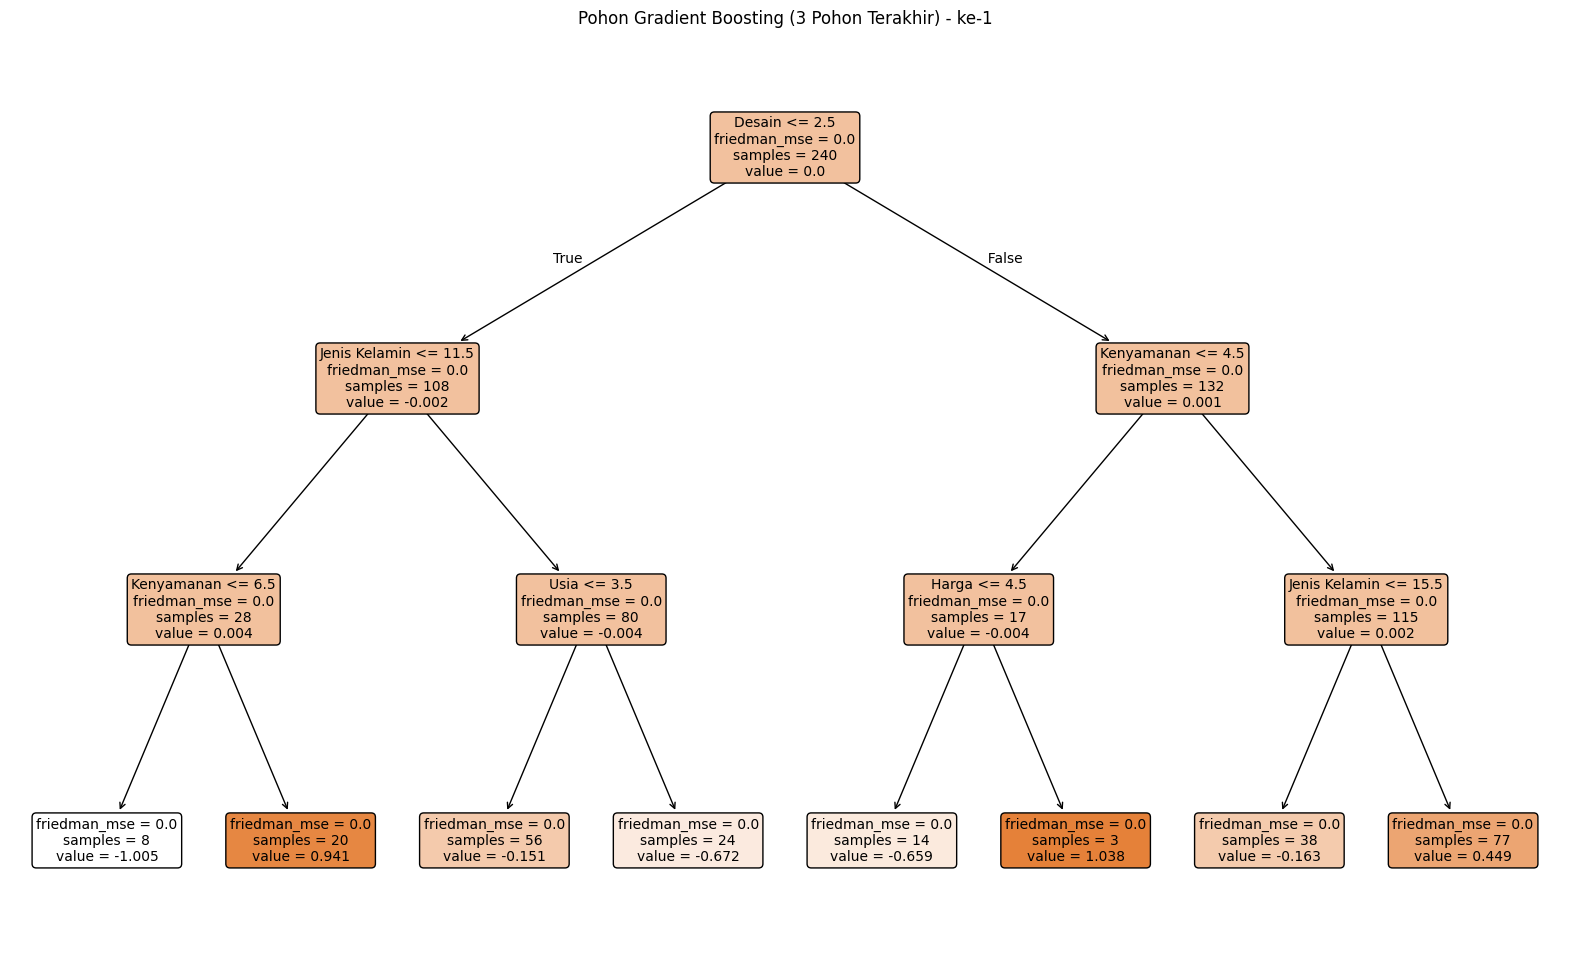

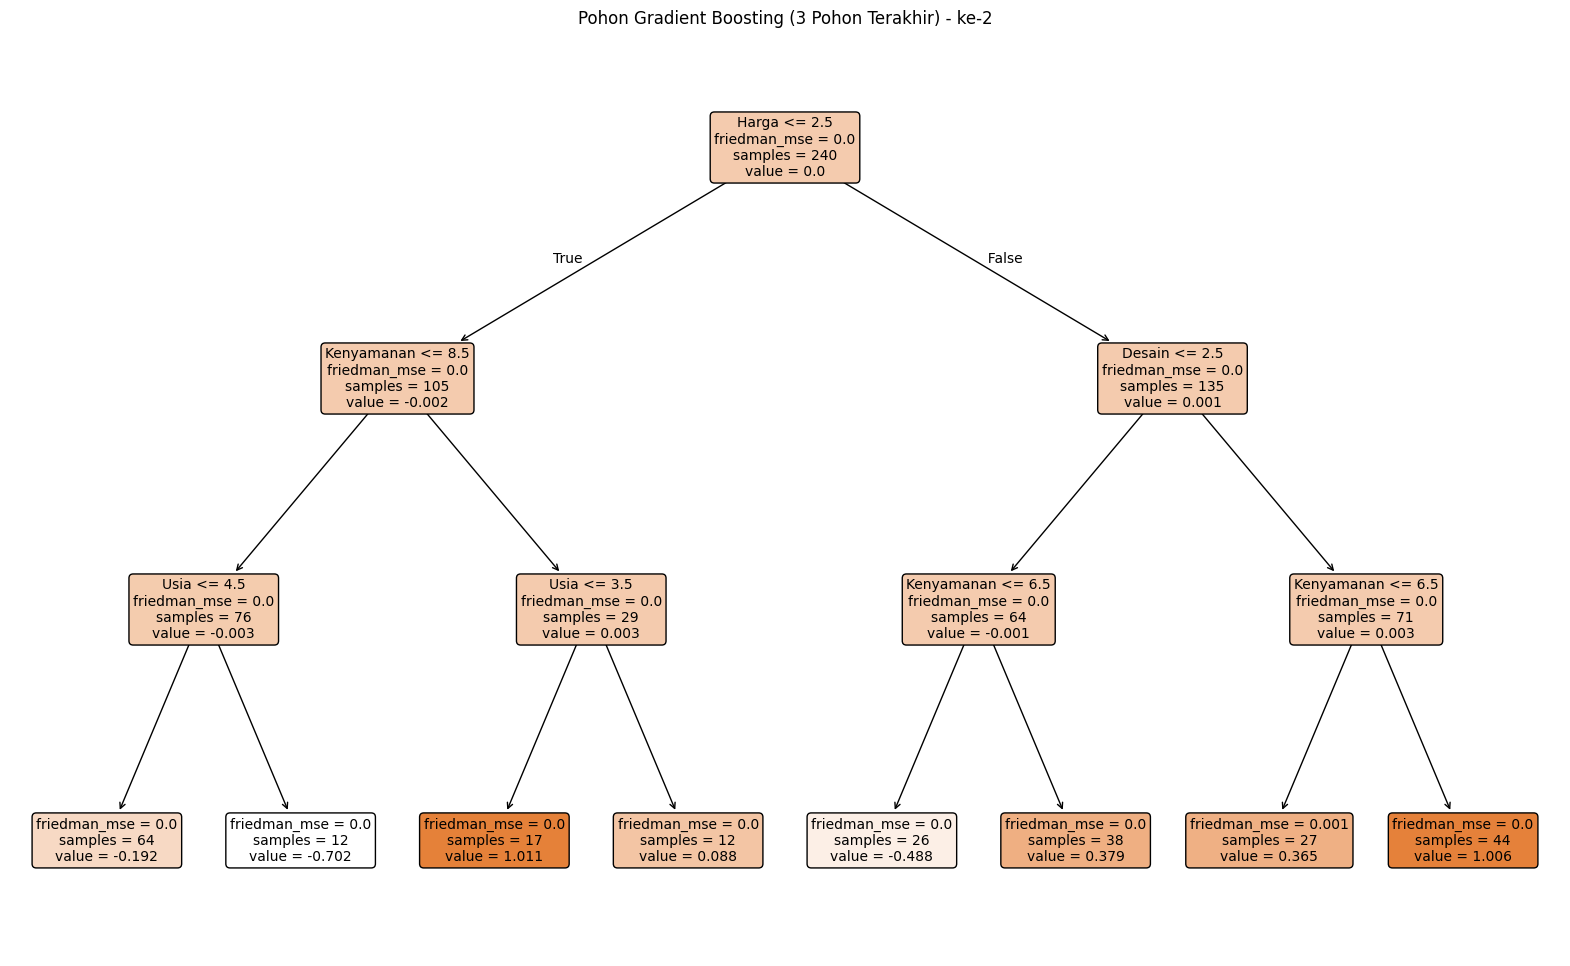

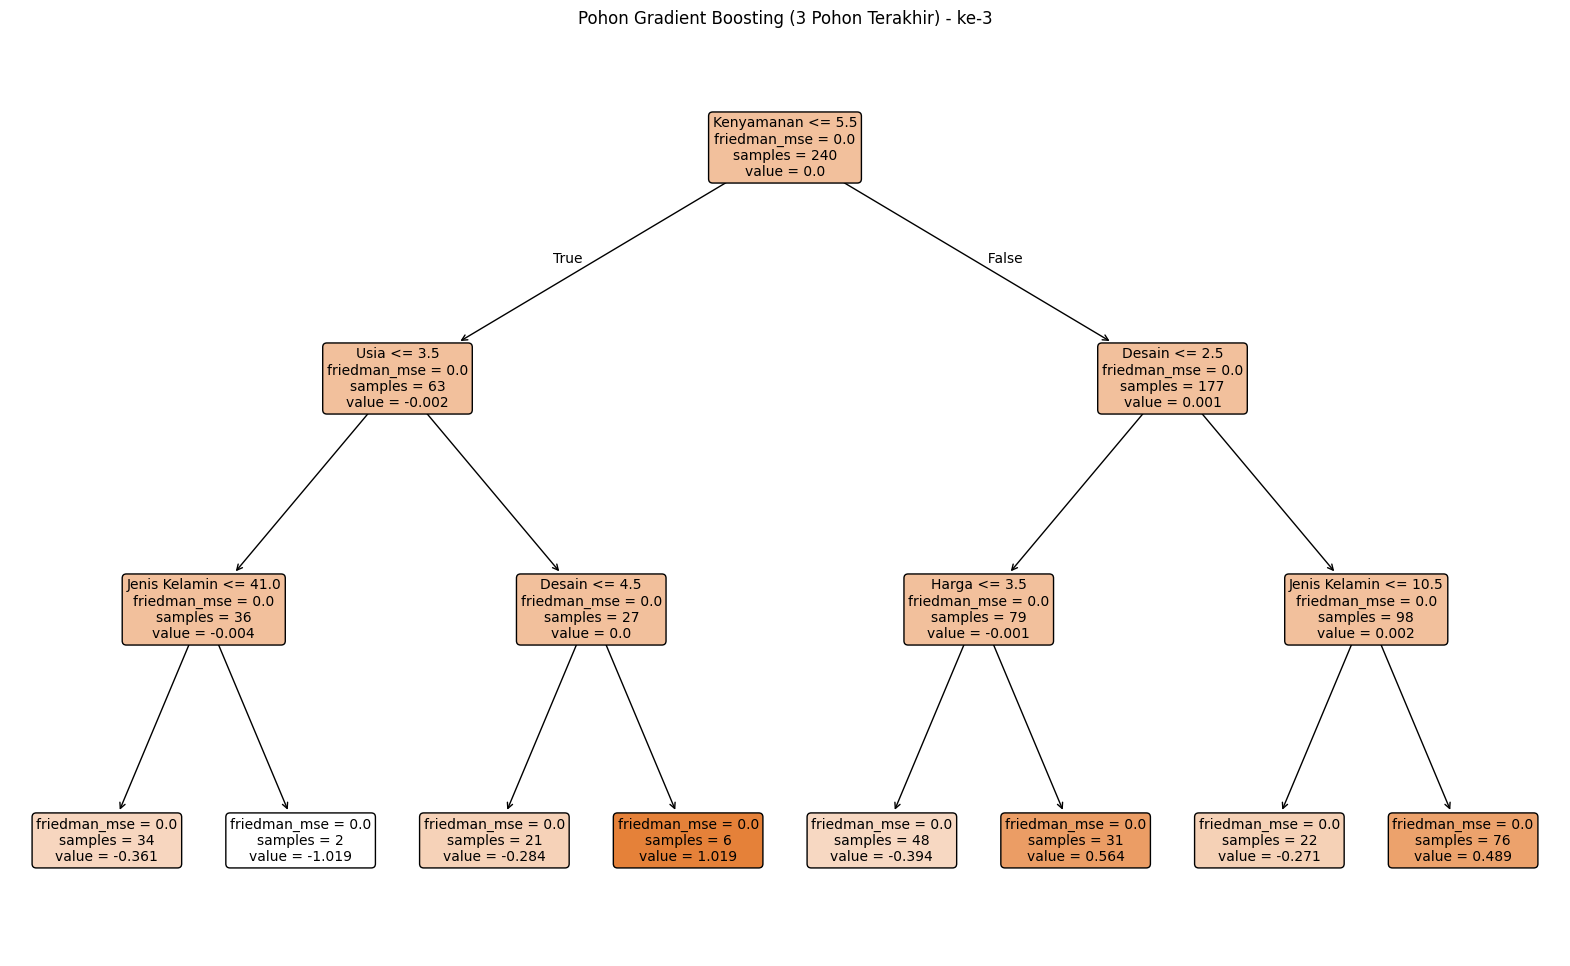

In [11]:
from sklearn.tree import plot_tree

# Ambil 3 pohon TERAKHIR dari Gradient Boosting
trees = model.estimators_[-3:]

for i, est in enumerate(trees, start=1):
    tree = est[0]  # pohon klasifikasi biner

    plt.figure(figsize=(20, 12))
    plot_tree(
        tree,
        feature_names=X.columns,
        class_names=['Tidak Premium', 'Premium'],
        filled=True,
        rounded=True,
        fontsize=10,
        impurity=True
    )
    plt.title(f'Pohon Gradient Boosting (3 Pohon Terakhir) - ke-{i}')
    plt.show()

## 9. Prediksi Data Baru

In [12]:
# [jenis_kelamin(0=L,1=P), usia, harga, desain, kenyamanan, durasi_tidur]
data_baru = [[1, 25, 5, 4, 5, 8]]

pred_baru = model.predict(data_baru)

print('Prediksi Suka Premium:', pred_baru[0])
print('Keterangan:', 'Menyukai Produk Premium' if pred_baru[0] == 1 else 'Tidak Menyukai Premium')

Prediksi Suka Premium: 1
Keterangan: Menyukai Produk Premium


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


## 10. Kesimpulan

In [13]:
akurasi = accuracy_score(y_test, y_pred)
print('\n============================')
print('KESIMPULAN MODEL GradientBoosting - DATA BANTAL')
print('============================')
print(f'Akurasi Model : {akurasi:.4f}')

if akurasi >= 0.85:
    kualitas = 'SANGAT BAIK'
elif akurasi >= 0.70:
    kualitas = 'CUKUP BAIK'
else:
    kualitas = 'RENDAH (perlu perbaikan)'

print(f'Kualitas Model : {kualitas}')


KESIMPULAN MODEL GradientBoosting - DATA BANTAL
Akurasi Model : 0.9180
Kualitas Model : SANGAT BAIK


## 11. Simpan Model

In [14]:
import pickle

with open('../flask-app/gb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('✅ Model berhasil disimpan: gb_model.pkl')

✅ Model berhasil disimpan: gb_model.pkl
